## Feature Engineering

Esse notebook faz parte do Tech Challenge da primeira fase da pós graduação de AI Scientist da FIAP. 

Esse projeto propõe que o grupo realize uma análise da base de dados de NPS de um e-commerce, buscando entender padrões que mais influenciam para tornar clientes promotores e detratores, sendo capaz de direcionar o time de negócios e tomada de decisões que buscam melhorar a experiência do cliente. 

O contexto, escopo e as métricas de avaliação desse projeto foram definidos anteriormente em outro documento. Em outro momento, foi realizado um Sanity Check dos dados disponibilizados. O objetivo desse notebook é preparar e construir novas variáveis a partir dos dados disponibilizados, que apoiarão na análise exploratória. 

**Fontes de dados**

- **desafio_nps_fase_1.csv:** arquivo CSV com as informações de clientes, pedidos e a nota NPS atribuída pelo cliente daquele pedido.

**Arquivos gerados**

- **desafio_nps_fase_1_feature_engineering.csv:** arquivo CSV com as colunas criadas no decorrer do notebook. 

**Features incluídas**

1. **faixa_etaria:** coluna categórica identificando a faixa etária de cada cliente.
2. **classificacao:** coluna categórica que classifica o cliente em Detrator, Neutro e Promotor.
3. **pct_desconto:** coluna que calcula a a proporção do desconto em relação ao valor total do item.
4. **flag_delay:** coluna booleana que identifica se a compra teve ou não atraso.
5. **freight_rate:** coluna que calcula a a proporção do frete em relação ao valor total do item.

### 0. Imports

In [2]:
import sys
import os
import pandas as pd
import numpy as np
sys.path.append(os.path.join(os.getcwd(), "..", "utils"))
from sanity_utils import *

### 1. Geração de parâmetros

In [3]:
par_source_nps = "desafio_nps_fase_1.csv"

### 2. Leitura de dados

In [4]:
df_nps = pd.read_csv(f"../dados/{par_source_nps}")

### 3. Construção de features

#### 3.1. Faixas etárias

In [5]:
valores_faixas_etarias = [18, 30, 60, np.inf]
labels_faixas_etarias = ['Jovem Adulto', 'Adulto', 'Idoso']

df_nps['faixa_etaria'] = pd.cut(df_nps['customer_age'], bins=valores_faixas_etarias, labels=labels_faixas_etarias)

In [6]:
df_nps['faixa_etaria'].value_counts(normalize=True).to_frame()

,proportion
faixa_etaria,
Adulto,0.603336
Jovem Adulto,0.227828
Idoso,0.168836


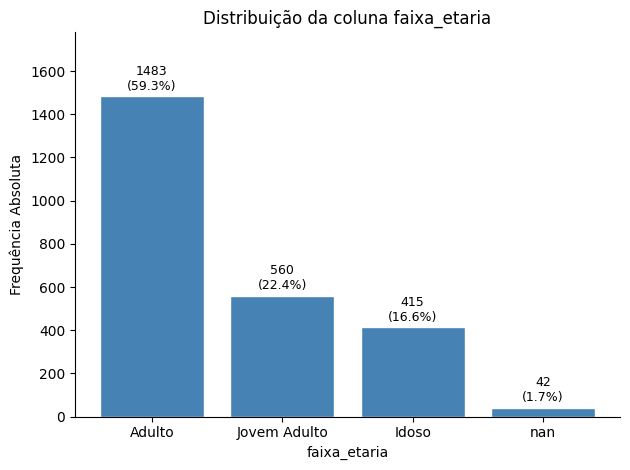

In [7]:
plota_bar(df_nps, 'faixa_etaria')

#### 3.2. Classificação das notas

In [8]:
valores_notas_nps = [0, 6, 8, 10]
labels_notas_nps = ['Detrator', 'Neutro', 'Promotor']

df_nps['classificacao'] = pd.cut(df_nps['nps_score'], bins=valores_notas_nps, labels=labels_notas_nps)

In [9]:
df_nps['classificacao'].value_counts(normalize=True).to_frame()

,proportion
classificacao,
Detrator,0.722886
Neutro,0.191289
Promotor,0.085824


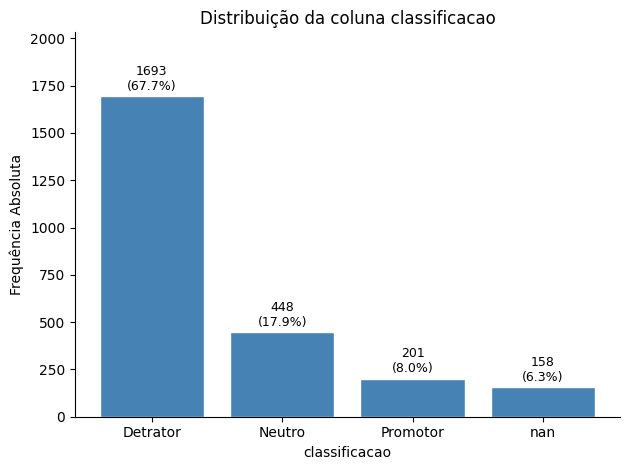

In [10]:
plota_bar(df_nps, 'classificacao')

#### 3.3. Taxa de desconto

In [11]:
df_nps['pct_desconto'] = round(df_nps['discount_value']/df_nps['order_value'], 2)

In [12]:
df_nps['pct_desconto'].describe().to_frame()

,pct_desconto
count,2500.000000
mean,0.125192
std,0.254153
min,0.000000
25%,0.020000
50%,0.060000
75%,0.130000
max,3.760000


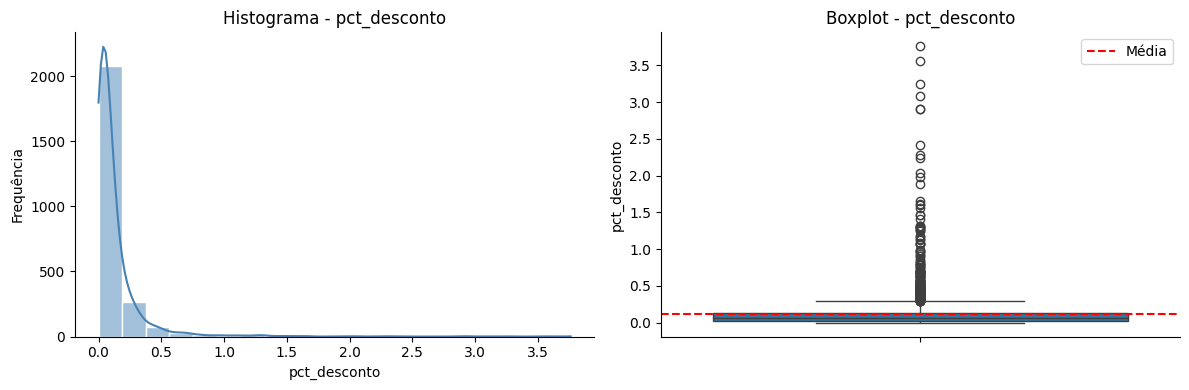

In [13]:
plota_histograma_e_boxplot(df_nps, 'pct_desconto', 20)

#### 3.4. Flag de pedido atrasado

In [14]:
df_nps['flag_delay'] =  df_nps['delivery_delay_days'] > 0

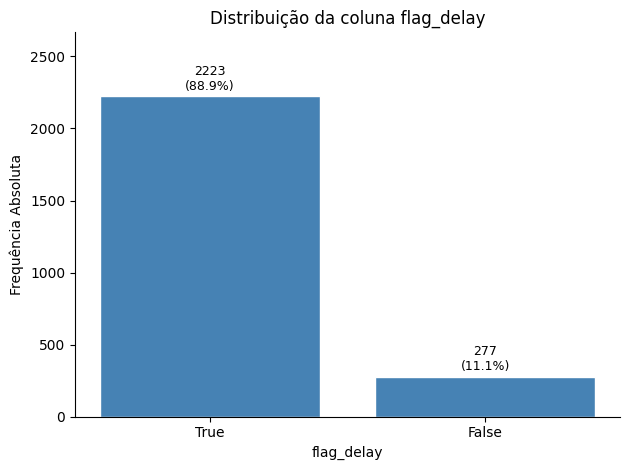

In [15]:
plota_bar(df_nps, 'flag_delay')

#### 3.5. Taxa do frete

In [16]:
df_nps['freight_rate'] = df_nps['freight_value']/df_nps['order_value']

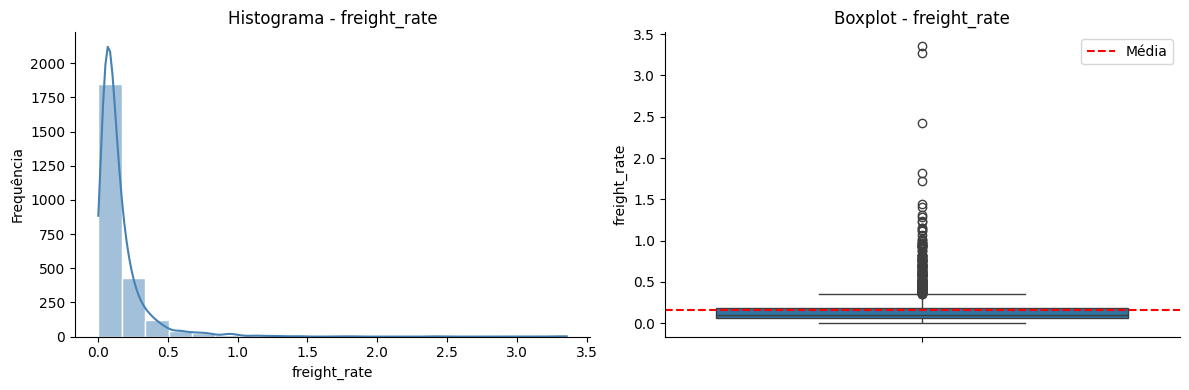

In [17]:
plota_histograma_e_boxplot(df_nps, 'freight_rate', 20)

### 4. Armazenamento da tabela

In [19]:
df_nps.to_csv("../dados/desafio_nps_fase_1_feature_engineering.csv")